In [1]:
# Cell 1: Imports and config
from pathlib import Path
import os
import yaml
import clip
from embedding import EmbeddingManager
from utils import get_domain_args
import numpy as np
from PIL import Image

# adjust these paths as needed
SOURCE_DOMAINS_YAML = Path("/home/chenyinjia/domain-lora/BLORA-SEG/Rebirth/Domain-Adaptation/config/source_domains.yaml")
LORA_LIBRARY_PATH = Path("/home/chenyinjia/domain-lora/BLORA-SEG/Rebirth/HugFace/lora-db")

import torch, gc
torch.cuda.set_device(0)
torch.cuda.empty_cache()
gc.collect()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


549

In [2]:
# Cell 2: helper
def load_source_domains(yaml_path: Path):
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)
    if isinstance(data, list):
        return data
    elif isinstance(data, dict):
        return list(data.keys())
    else:
        raise ValueError("source_domains.yaml should be a list or mapping")

def safe_mean_embeddings(emb_list):
    if not emb_list:
        return None
    arrs = []
    for e in emb_list:
        a = np.asarray(e)
        if a.ndim == 2 and a.shape[0] == 1:
            a = a.reshape(-1)
        arrs.append(a)
    stacked = np.stack(arrs, axis=0)
    return np.mean(stacked, axis=0)


In [3]:
# Cell 3: create embedding manager
embedding_manager = EmbeddingManager()
print("EmbeddingManager created:", embedding_manager)
img_path = Path("/home/chenyinjia/data/dataset/acdc/rgb_anon/rain/train/GOPR0402/GOPR0402_frame_000485_rgb_anon.png")
# quick device / model status check (optional)
try:
    emb = embedding_manager.embed_image(img_path)
    print("Sample embedding shape:", np.asarray(emb).shape)
except Exception as e:
    print(e)


EmbeddingManager created: <embedding.EmbeddingManager object at 0x7f19c80fb6a0>
Sample embedding shape: (1, 768)


# Model Character
-                                      image_size, patch_size, image_hidden_size, text_hidden_size, proj_dim

- openai/clip-vit-base-patch32 (600M):      224,       32,            768,               512,          512
- openai/clip-vit-base-patch16 (600M):      224,       16,            768,               512,          512
- openai/clip-vit-large-patch14 (1.7G):     224,       14,            1024,              768,          768
- openai/clip-vit-large-patch14-336 (1.7G): 336,       14,            1024,              768,          768

In [4]:
from transformers import CLIPModel, CLIPProcessor
embedding_model = CLIPModel.from_pretrained(
            "/home/chenyinjia/clip-vit-large-patch14"               # "openai/clip-vit-large-patch14"    
        ).to("cuda")                                                # Load form Local
embedding_processor = CLIPProcessor.from_pretrained(
            "/home/chenyinjia/clip-vit-large-patch14"               # "openai/clip-vit-large-patch14"
        )      
print(type(embedding_model), type(embedding_processor))

import clip 
model, processor  = clip.load("ViT-B/16", device="cuda")
print(type(model), type(processor))


<class 'transformers.models.clip.modeling_clip.CLIPModel'> <class 'transformers.models.clip.processing_clip.CLIPProcessor'>
<class 'clip.model.CLIP'> <class 'torchvision.transforms.transforms.Compose'>


In [5]:
image = Image.open(img_path).convert("RGB")
inputs = embedding_processor(images=image, return_tensors="pt").to("cuda")

image_embeddings = (
                embedding_model.get_image_features(**inputs).detach().cpu().numpy()
            )
print(type(image_embeddings), image_embeddings.shape)
# print(image_embeddings)

<class 'numpy.ndarray'> (1, 768)


In [6]:
inputs = processor(image).unsqueeze(0).to("cuda")
image_embeddings = (
                model.encode_image(inputs).detach().cpu().numpy()
            )
print(type(image_embeddings), image_embeddings.shape)

<class 'numpy.ndarray'> (1, 512)


In [7]:
source_domains = load_source_domains(SOURCE_DOMAINS_YAML)
source_domains

['ACDC-fog',
 'ACDC-night',
 'ACDC-rain',
 'ACDC-snow',
 'ADE20K',
 'Cityscapes',
 'MUSES-clear',
 'MUSES-fog',
 'MUSES-rain',
 'MUSES-snow',
 'BDD',
 'MV']

In [8]:
# Cell 4: main generation loop
source_domains = load_source_domains(SOURCE_DOMAINS_YAML)
LORA_LIBRARY_PATH.mkdir(parents=True, exist_ok=True)

for domain_name in source_domains:
    print(f"\nProcessing domain: {domain_name}")
    args = get_domain_args(domain_name, "train", get_cofing_only=True)
    train_dataset_path = Path(args.train_dataset_path)
    print(" train path:", train_dataset_path)

    if not train_dataset_path.exists():
        print(" ❌ ERROR: train path does not exist, skipping")
        continue

    domain_path = LORA_LIBRARY_PATH / domain_name
    domain_path.mkdir(parents=True, exist_ok=True)

    stats_file = domain_path / f"{domain_name}_statistics.npz"

    if stats_file.exists():
        print(" ❌ stats already exists at", stats_file, "- skipping (delete to recompute)")
        continue

    
    dataset_embeddings = embedding_manager.embed_dataset(train_dataset_path)
    print(f"\n  embedding dataset {len(dataset_embeddings)}...")
    if not dataset_embeddings:
        print(" ❌ no embeddings - skipping")
        continue

    train_avg = safe_mean_embeddings(dataset_embeddings)
    if train_avg is None:
        print("  ❌ failed to compute mean - skipping")
        continue

    np.savez(stats_file, train_average_embedding=train_avg)
    print("  saved stats to", stats_file)

# print("\nDone.")



Processing domain: ACDC-fog
 train path: /home/chenyinjia/data/dataset/acdc/rgb_anon/fog/train
 ❌ stats already exists at /home/chenyinjia/domain-lora/BLORA-SEG/Rebirth/HugFace/lora-db/ACDC-fog/ACDC-fog_statistics.npz - skipping (delete to recompute)

Processing domain: ACDC-night
 train path: /home/chenyinjia/data/dataset/acdc/rgb_anon/night/train
 ❌ stats already exists at /home/chenyinjia/domain-lora/BLORA-SEG/Rebirth/HugFace/lora-db/ACDC-night/ACDC-night_statistics.npz - skipping (delete to recompute)

Processing domain: ACDC-rain
 train path: /home/chenyinjia/data/dataset/acdc/rgb_anon/rain/train
 ❌ stats already exists at /home/chenyinjia/domain-lora/BLORA-SEG/Rebirth/HugFace/lora-db/ACDC-rain/ACDC-rain_statistics.npz - skipping (delete to recompute)

Processing domain: ACDC-snow
 train path: /home/chenyinjia/data/dataset/acdc/rgb_anon/snow/train
 ❌ stats already exists at /home/chenyinjia/domain-lora/BLORA-SEG/Rebirth/HugFace/lora-db/ACDC-snow/ACDC-snow_statistics.npz - skippin

In [9]:
def load_or_compute_embeddings(domain_name, force_recompute=False):
    domain_dir = LORA_LIBRARY_PATH / domain_name
    stats_file = domain_dir / f"{domain_name}_statistics.npz"

    args = get_domain_args(domain_name, "train", get_cofing_only=True)
    train_path = Path(args.train_dataset_path)

    # Load all embeddings (not centroid) if exist
    per_image_emb_file = domain_dir / f"{domain_name}_all_embeddings.npy"

    if per_image_emb_file.exists() and not force_recompute:
        print(f"[{domain_name}] Loading cached dataset embeddings...")
        return np.load(per_image_emb_file)

    print(f"[{domain_name}] Embedding dataset: {train_path}")

    image_paths = list(train_path.rglob("*.jpg")) + list(train_path.rglob("*.png"))

    all_embs = []
    for img_path in image_paths:
        emb = embedding_manager.embed_image(img_path)
        emb = np.asarray(emb).reshape(-1)  # flatten
        all_embs.append(emb)

    all_embs = np.array(all_embs)

    # Cache result
    domain_dir.mkdir(parents=True, exist_ok=True)
    np.save(per_image_emb_file, all_embs)

    return all_embs

In [10]:
def load_domain_centroid(domain_name):
    domain_dir = LORA_LIBRARY_PATH / domain_name
    stats_file = domain_dir / f"{domain_name}_statistics.npz"
    emb = np.load(stats_file)["train_average_embedding"]
    return emb.reshape(1, -1)


In [11]:
c = load_domain_centroid("ADE20K")
c.shape

(1, 768)

In [42]:
import random
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

all_domain_data = []
all_domain_labels = []
centroids = []
centroid_labels = []

# t-SNE parameters
TSNE_FIT_MAX = 5000       # max samples used for t-sne fit per dataset
PLOT_FRACTION = 0.3       # fraction of t-sne points to show in plot
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

for domain_name in source_domains:
    print(f"\n--- Processing {domain_name} ---")

    # Load dataset embeddings
    data = load_or_compute_embeddings(domain_name)

    # Limit number of samples used in TSNE fit
    if len(data) > TSNE_FIT_MAX:
        idx = np.random.choice(len(data), TSNE_FIT_MAX, replace=False)
        data = data[idx]

    # Add to global list
    all_domain_data.append(data)
    all_domain_labels += [domain_name] * len(data)

    # Load centroid
    c = load_domain_centroid(domain_name)
    centroids.append(c)
    centroid_labels.append(domain_name)

# Concatenate
X_data = np.vstack(all_domain_data)
X_centroids = np.vstack(centroids)

print("\nFinal shapes:")
print("  X_data:", X_data.shape)
print("  X_centroids:", X_centroids.shape)



--- Processing ACDC-fog ---
[ACDC-fog] Loading cached dataset embeddings...

--- Processing ACDC-night ---
[ACDC-night] Loading cached dataset embeddings...

--- Processing ACDC-rain ---
[ACDC-rain] Loading cached dataset embeddings...

--- Processing ACDC-snow ---
[ACDC-snow] Loading cached dataset embeddings...

--- Processing ADE20K ---
[ADE20K] Loading cached dataset embeddings...

--- Processing Cityscapes ---
[Cityscapes] Loading cached dataset embeddings...

--- Processing MUSES-clear ---
[MUSES-clear] Loading cached dataset embeddings...

--- Processing MUSES-fog ---
[MUSES-fog] Loading cached dataset embeddings...

--- Processing MUSES-rain ---
[MUSES-rain] Loading cached dataset embeddings...

--- Processing MUSES-snow ---
[MUSES-snow] Loading cached dataset embeddings...

--- Processing BDD ---
[BDD] Loading cached dataset embeddings...

--- Processing MV ---
[MV] Loading cached dataset embeddings...

Final shapes:
  X_data: (21075, 768)
  X_centroids: (12, 768)


In [43]:
5000+2975+1600+1500

11075

In [44]:
# ==== Combine data + centroids ====
X_total = np.vstack([X_data, X_centroids])

# ==== Run TSNE on combined ====
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    max_iter=1000,
    init="random"
)
X_total_tsne = tsne.fit_transform(X_total)

# ==== Split back ====
X_tsne = X_total_tsne[:len(X_data)]
X_centroids_tsne = X_total_tsne[len(X_data):]


In [45]:
# print("Running t-SNE on dataset embeddings...")

# tsne = TSNE(
#     n_components=2,
#     perplexity=40,
#     learning_rate='auto', # 200,
#     max_iter=1000,
#     # verbose=1,
#     init="random"
# )

# X_tsne = tsne.fit_transform(X_data)

# # Project centroids using neighborhood interpolation
# def project_centroid(centroid, X, X_tsne, k=50):
#     # find nearest neighbors
#     d = np.linalg.norm(X - centroid, axis=1)
#     idx = np.argsort(d)[:k]
#     # weighted average in t-SNE space
#     # weighted average in t-SNE space
#     weights = 1 / (d[idx] + 1e-8)
#     weights /= weights.sum()
#     return (X_tsne[idx] * weights[:, None]).sum(axis=0)

# X_centroids_tsne = np.array([
#     project_centroid(c, X_data, X_tsne) for c in X_centroids
# ])


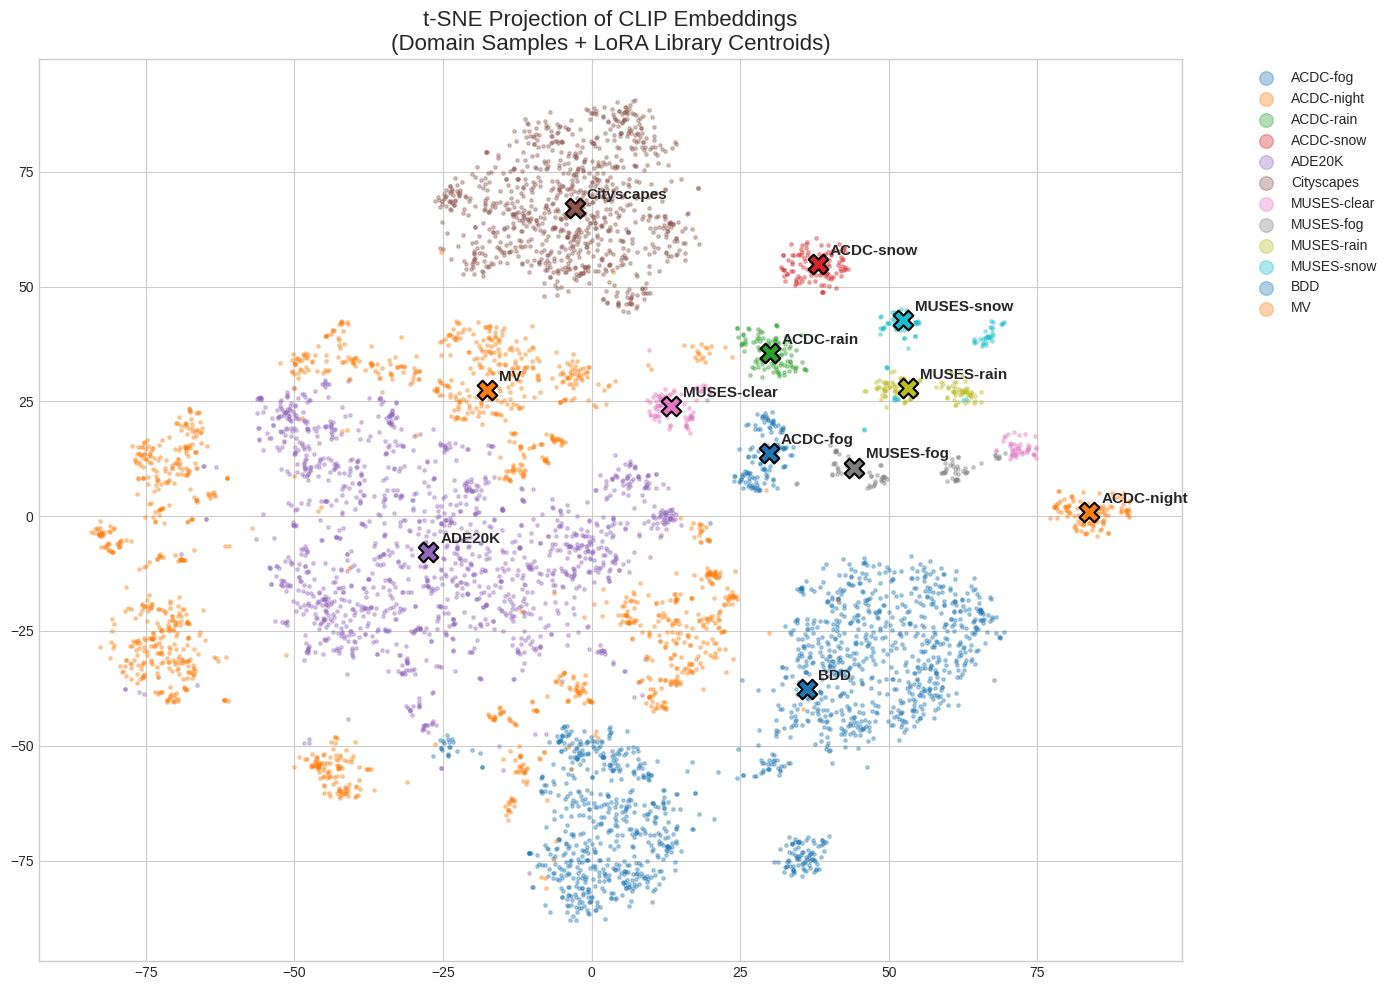

In [46]:
N = len(X_tsne)
plot_idx = np.random.choice(N, int(N * PLOT_FRACTION), replace=False)

X_plot = X_tsne[plot_idx]
labels_plot = [all_domain_labels[i] for i in plot_idx]

unique_domains = source_domains   
colors = list(mcolors.TABLEAU_COLORS.values())

domain_to_color = {d: colors[i % len(colors)] for i, d in enumerate(unique_domains)}

plt.figure(figsize=(14, 10))

# scatter dataset samples
for d in unique_domains:
    mask = [i for i, lbl in enumerate(labels_plot) if lbl == d]
    if len(mask) > 0:
        plt.scatter(
            X_plot[mask, 0],
            X_plot[mask, 1],
            c=domain_to_color[d],
            label=d,
            alpha=0.35,
            s=6
        )

# plot centroids
for i, d in enumerate(unique_domains):
    plt.scatter(
        X_centroids_tsne[i, 0],
        X_centroids_tsne[i, 1],
        c=domain_to_color[d],
        edgecolor="black",
        s=200,
        marker="X",
        linewidths=1.5
    )
    plt.text(
        X_centroids_tsne[i, 0] + 2,
        X_centroids_tsne[i, 1] + 2,
        d,
        fontsize=11,
        weight="bold"
    )

plt.title("t-SNE Projection of CLIP Embeddings\n(Domain Samples + LoRA Library Centroids)", fontsize=16)
plt.legend(markerscale=4, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


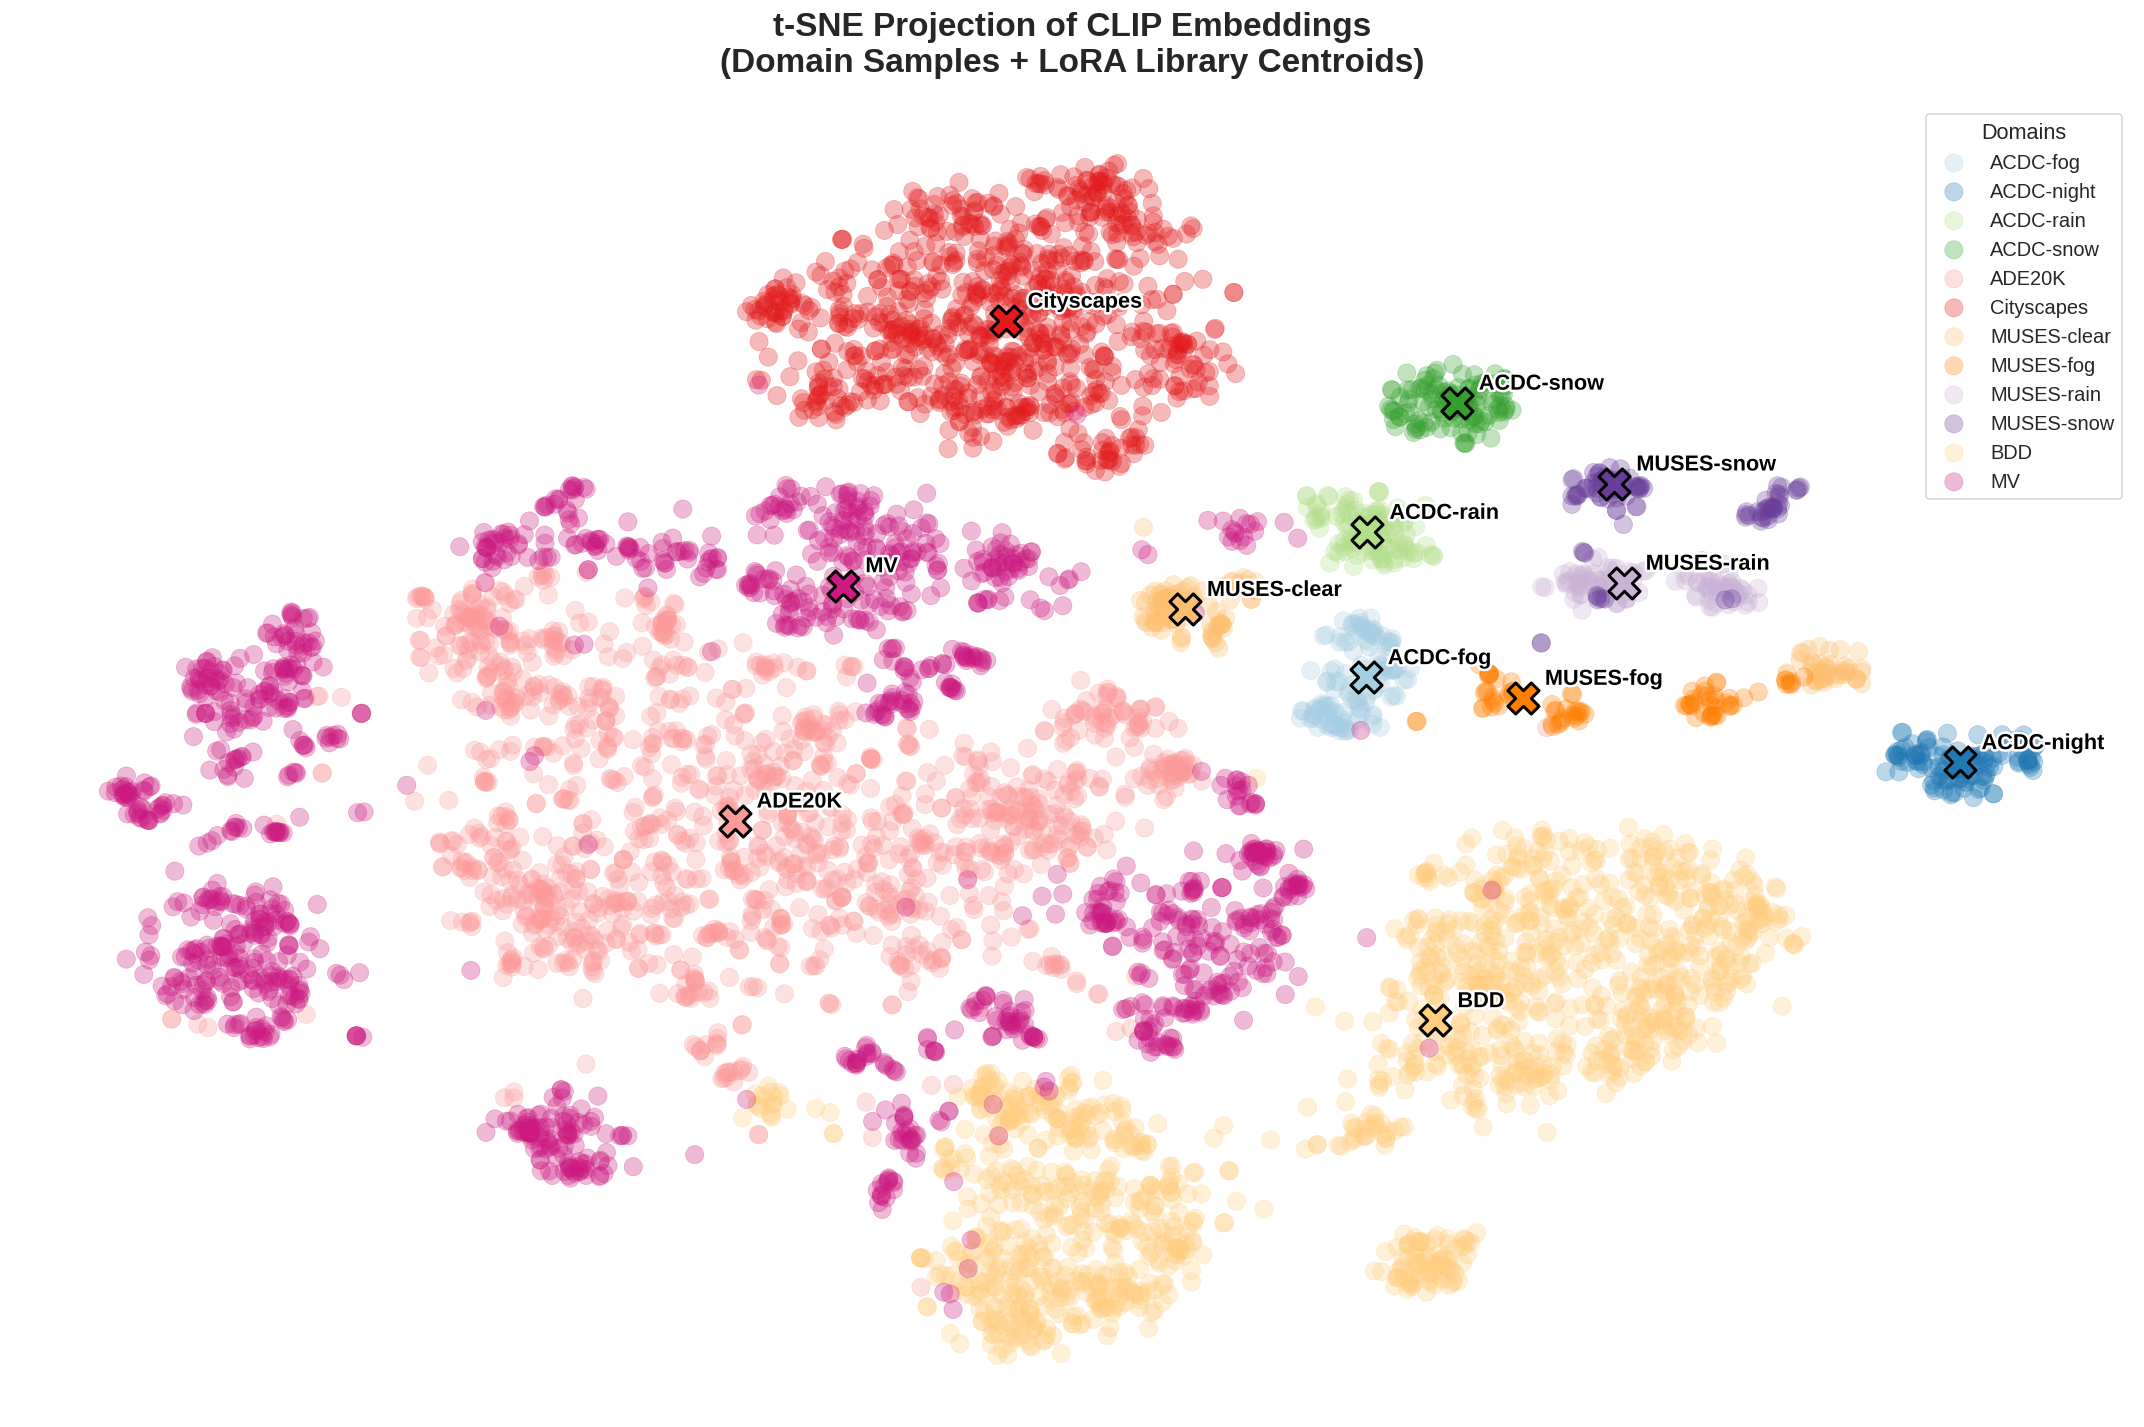

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import seaborn as sns

# Use publication style
plt.style.use("seaborn-v0_8-whitegrid")

# beautiful scientific palette
palette = sns.color_palette("Paired", len(unique_domains))
palette[-2] = (1, 0.807843137254902, 0.5)
palette[-1] = (0.8, 0.1, 0.5)
domain_to_color = {d: palette[i] for i, d in enumerate(unique_domains)}

plt.figure(figsize=(18, 12), dpi=120)

# scatter dataset samples
for d in unique_domains:
    mask = [i for i, lbl in enumerate(labels_plot) if lbl == d]
    if len(mask) > 0:
        plt.scatter(
            X_plot[mask, 0],
            X_plot[mask, 1],
            c=[domain_to_color[d]] * len(mask),
            label=d,
            alpha=0.3,
            s=120,
            linewidths=0.4,
        )

# plot centroids
for i, d in enumerate(unique_domains):
    # centroid point
    sc = plt.scatter(
        X_centroids_tsne[i, 0],
        X_centroids_tsne[i, 1],
        c=[domain_to_color[d]],
        s=350,
        marker="X",
        edgecolor="black",
        linewidths=1.8,
        zorder=5
    )

    # centroid text with stroke for readability
    txt = plt.text(
        X_centroids_tsne[i, 0] + 2,
        X_centroids_tsne[i, 1] + 2,
        d,
        fontsize=13,
        weight="bold",
        color="black",
        zorder=6
    )
    txt.set_path_effects([
        PathEffects.Stroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

plt.title(
    "t-SNE Projection of CLIP Embeddings\n"
    "(Domain Samples + LoRA Library Centroids)",
    fontsize=20,
    weight="bold",
    pad=20
)

# make legend prettier
plt.legend(
    # markerscale=2.2,
    # bbox_to_anchor=(1.03, 1),
    loc="upper right",
    frameon=True,
    fontsize=12,
    title="Domains",
    title_fontsize=13
)
# plt.ylim(-75, 75)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.box(False)

# plt.xlabel("t-SNE dimension 1", fontsize=14)
# plt.ylabel("t-SNE dimension 2", fontsize=14)

plt.tight_layout()
plt.show()


In [48]:
len(palette), len(unique_domains)

(12, 12)

In [51]:
palette[0]

(0.6509803921568628, 0.807843137254902, 0.8901960784313725)